# 🏥 Patient Recovery Prediction using Multiple Regression
### Supervised Machine Learning — Multi-Output Regression
---

## 📌 Problem Statement

A hospital wants to predict **two recovery outcomes** for patients based on their health profile and treatment plan:

| Target Variable | Description |
|---|---|
| `Recovery_Days` | Number of days until the patient is discharged |
| `Pain_Reduction_Score` | Score (0–100) indicating how much pain was reduced |

**Input Features:** Age, BMI, Blood Pressure, Therapy Hours, Medication Dosage, Pre-existing Conditions Score

**Why Multiple Regression with Two Targets?**
- Standard linear regression predicts **one** target at a time.
- `MultiOutputRegressor` wraps a base model to **independently predict each target** simultaneously.
- This is more efficient and convenient than running two separate models.

---

## Step 1 — Import Libraries

> We use `MultiOutputRegressor` from `sklearn.multioutput` — it wraps a base estimator
> and fits one regressor **per target column** automatically.


In [54]:
# Write your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 2 — Load Dataset

> The dataset contains **120 patient records** with 6 features and **2 target variables**.
> A few missing values exist in `Blood_Pressure` and `Medication_Dosage` — we will handle them in Step 3.


In [55]:
# Write your code here
df = pd.read_csv('patient_recovery_data.csv')
print(f'Shape: {df.shape}')
df.head()
df.isnull().sum()
df.fillna(df.mean(), inplace=True)
print('after null fill:', df.isnull().sum().sum() )

Shape: (120, 8)
after null fill: 0


## Step 3 — Exploratory Data Analysis (EDA)

> EDA helps us understand the data distribution, spot missing values, and see correlations.


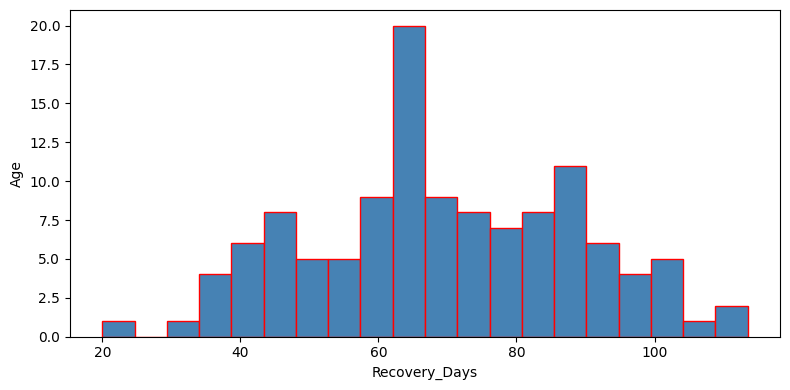

In [56]:
# Write your code here
plt.figure(figsize=(8,4))
plt.hist(df['Recovery_Days'],bins=20,color='steelblue',edgecolor='red')
plt.xlabel('Recovery_Days')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

In [57]:
# Write your code here


### 3a — Fill Missing Values

> We fill missing values using the **column mean** — a simple and effective strategy for numerical features.
> ⚠️ Important: we fill the **entire dataframe** here before splitting (a simpler approach for beginners).
> In Step 6, we will show the production-safe method using only training data means.


In [58]:
# Write your code here



## Step 4 — Define Features & Targets

> - **X** = input features (the predictors the model learns from)
> - **y** = output targets — here we have **two columns** (multi-output)
>
> Unlike single-output regression where `y` is a 1-D array, here `y` is a **2-D DataFrame**
> with shape `(n_samples, 2)`.


In [59]:
# Write your code here
features = ['Age',	'BMI',	'Blood_Pressure',	'Therapy_Hours',
	'Medication_Dosage',	'Preexisting_Score']
targets = ['Recovery_Days','Pain_Reduction_Score']
x = df[features]
y = df[targets]

print(f'features shape: {features}')
print(f'yshape: {y.shape}')
#print(f'zshape: {z.shape}') 

features shape: ['Age', 'BMI', 'Blood_Pressure', 'Therapy_Hours', 'Medication_Dosage', 'Preexisting_Score']
yshape: (120, 2)


## Step 5 — Train / Test Split

> We reserve **20%** of data for testing and train on the remaining **80%**.
> `random_state=42` makes the split reproducible.


In [60]:
# Write your code here
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state= 42
)
print(f'train samples: {x_train.shape[0]}')
print(f'test samples: {x_test.shape[0]}')

train samples: 96
test samples: 24


## Step 6 — Handle Missing Values in Test Data (Safe Method)

> ⚠️ **Data Leakage Warning**
>
> When filling missing values, always use statistics computed **only from training data**.
> Using test-set statistics to fill missing values 'leaks' future information into training.
> Here we compute the mean from `X_train` and apply it to both sets.


In [61]:
# Write your code here
train_mean = x_train.mean()
test_mean = x_test.mean()
x_train = x_train.fillna(train_mean)
x_test = x_test.fillna(test_mean)
print('After fill na train: ', x_train.isnull().sum())
print('after fill na test:' , x_test.isnull().sum())

After fill na train:  Age                  0
BMI                  0
Blood_Pressure       0
Therapy_Hours        0
Medication_Dosage    0
Preexisting_Score    0
dtype: int64
after fill na test: Age                  0
BMI                  0
Blood_Pressure       0
Therapy_Hours        0
Medication_Dosage    0
Preexisting_Score    0
dtype: int64


In [62]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print('Train and test model scalled')

Train and test model scalled


## Step 8 — Build & Train the Multi-Output Model

> `MultiOutputRegressor(LinearRegression())` trains **one Linear Regression model per target**.
>
> Internally it fits:
> - Model A → predicts `Recovery_Days`
> - Model B → predicts `Pain_Reduction_Score`
>
> Both models share the same input features `X_train`.


In [63]:
# Write your code here
base_model = LinearRegression()
model = MultiOutputRegressor(base_model)

model.fit(x_train,y_train)
print('Model Trained')

# Access intercepts for each target separately
print(f'\nIntercept for Recovery_Days: {model.estimators_[0].intercept_:.2f}')
print(f'Intercept for Pain_Reduction_Score: {model.estimators_[1].intercept_:.2f}')

# Coefficients for each target
coef_df_recovery = pd.DataFrame({
    'Feature': features,
    'Coefficient (Recovery_Days)': model.estimators_[0].coef_
})
coef_df_pain = pd.DataFrame({
    'Feature': features,
    'Coefficient (Pain_Reduction_Score)': model.estimators_[1].coef_
})

print('\nCoefficients for Recovery_Days:')
print(coef_df_recovery.to_string(index=False))
print('\nCoefficients for Pain_Reduction_Score:')
print(coef_df_pain.to_string(index=False))


Model Trained

Intercept for Recovery_Days: 70.44
Intercept for Pain_Reduction_Score: 1.66

Coefficients for Recovery_Days:
          Feature  Coefficient (Recovery_Days)
              Age                     7.508459
              BMI                    11.183656
   Blood_Pressure                     1.940902
    Therapy_Hours                   -11.393670
Medication_Dosage                     1.714502
Preexisting_Score                     7.138135

Coefficients for Pain_Reduction_Score:
          Feature  Coefficient (Pain_Reduction_Score)
              Age                           -0.879065
              BMI                           -0.969624
   Blood_Pressure                           -0.424975
    Therapy_Hours                            2.411090
Medication_Dosage                            0.728222
Preexisting_Score                           -1.442954


## Step 9 — Evaluate the Model

> We evaluate **each target separately** using three metrics:
>
> | Metric | Formula | What it means |
> |---|---|---|
> | **MAE** | avg(\|actual − predicted\|) | Average error in original units |
> | **RMSE** | √avg((actual − predicted)²) | Penalises large errors more |
> | **R²** | 1 − SS_res/SS_tot | % of variance explained (1.0 = perfect) |



### Evaluation Metric Formulas

**Mean Absolute Error (MAE):**
$$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $$

**Root Mean Squared Error (RMSE):**
$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

**R² (Coefficient of Determination):**
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

Where $y_i$ = actual, $\hat{y}_i$ = predicted, $\bar{y}$ = mean of actuals, $n$ = test samples


In [ ]:
# Write your code here
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2= r2_score(y_test, y_pred)

print(f'mae: {mae:,.2f}')
print (f'rmse: {rmse:,.2f}')
print(f'R2:{r2:.4f}')
print(f'\n R2 of {r2:.2f} means the model explains {r2*100:.1f}% of the varience in patient recovery ')

mae: 3.42
rmse: 4.64
R2:0.6186

 R2 of 0.62 means the model explains 61.9% of the varience in patient recovery 


## Step 10 — Visualise Actual vs Predicted

> A scatter plot of **Actual vs Predicted** values is a quick sanity check.
> Points close to the diagonal line (y = x) indicate good predictions.


In [65]:
# Write your code here


## Step 11 — Predict on New Patient Data

> Now we use the trained model to predict outcomes for **two new patients**.
> The new data must be scaled using the **same scaler fitted on training data**.


In [66]:
# Write your code here
new_patients = pd.DataFrame({
    'Age'               : [45,  72 ],
    'BMI'               : [24.5, 31.2],
    'Blood_Pressure'    : [120, 145 ],
    'Therapy_Hours'     : [12,   5  ],
    'Medication_Dosage' : [50,  80  ],
    'Preexisting_Score' : [2,    7  ]
})

# Fill any missing (none here, but good practice) then scale
new_patients_filled = new_patients.fillna(train_mean)
new_patients_scaled = scaler.transform(new_patients_filled)

preds = model.predict(new_patients_scaled)

new_patients['Predicted_Recovery_Days']      = preds[:, 0].round(1)
new_patients['Predicted_Pain_Reduction']     = preds[:, 1].round(1)

print('🏥 Predicted Patient Outcomes:')
print(new_patients.to_string(index=False))

🏥 Predicted Patient Outcomes:
 Age  BMI  Blood_Pressure  Therapy_Hours  Medication_Dosage  Preexisting_Score  Predicted_Recovery_Days  Predicted_Pain_Reduction
  45 24.5             120             12                 50                  2                     52.0                       4.2
  72 31.2             145              5                 80                  7                    105.0                      -3.3
